# 1.2.1 一段时间的物质收支

## 学习目标与先修知识

- 区分存量（stock）、流量（flow）与一个时段内累计转移的量。
- 按各段时长计算收支（mass balance），用总账核对逐步计算。
- 将负所追踪物质总量（tracked amount）识别为假设失效的线索。

**先修知识**：[单位、量纲与时间序列](../01-从生理现象提出系统问题/02-单位量纲与时间序列.ipynb)；乘法、循环与列表追加。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

把体内某种物质暂时看成一个容器内的量 A。起点为 5 U，流入 3 U/T，流出 1 U/T。第一段持续 1 T，第二段持续 2 T，其中 T 是固定的时间单位。

先算每段实际流进、流出多少。两段的速率相同，累计量会相同吗？

In [1]:
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
initial = 5
durations = [1, 2]
inflows = [3, 3]
outflows = [1, 1]
rows = [(i+1, h, h*u, h*v) for i, (h,u,v) in enumerate(zip(durations,inflows,outflows))]
display(Markdown(show_table(['区间', '持续 / T', '累计流入 / U', '累计流出 / U'], rows)))

| 区间 | 持续 / T | 累计流入 / U | 累计流出 / U |
| --- | --- | --- | --- |
| 1 | 1 | 3 | 1 |
| 2 | 2 | 6 | 2 |

## 模型假设

所选系统边界（system boundary）只包围这个容器；流入与流出是跨边界转移。我们追踪的物质不在内部生成、消失或转化，每段内的速率恒定。段与段之间可以改变速率。

| 符号 | 含义 | 单位 |
|---|---|---|
| A | 某个时刻已经拥有的总量，即存量 | U |
| u、v | 每单位时间流入、流出的量，即流率（flow rate） | U/T |
| h | 这一个区间的持续时间 | T |
| hu、hv | 此区间累计转移量 | U |

本节的流量专指流率（flow rate），不是已经累计的转移量。看到一个数值时，先问它是“现在有多少”还是“每单位时间通过多少”。

## 数学解释与推导

恒定流入速率 u 持续 h 个时间单位，累计流入就是 hu。守恒账目为

$$A_{\text{末}}=A_{\text{初}}+hu-hv=A_{\text{初}}+h(u-v).$$

右边三项都为 U。第一段末 $5+1(3-1)=7$ U；第二段以 7 为新起点，得到 $7+2(3-1)=11$ U。这里是分段算术，不需要先学微积分。

逐段循环的最终答案还应满足另一张总账：终点减起点，等于所有段的累计流入之和减累计流出之和。

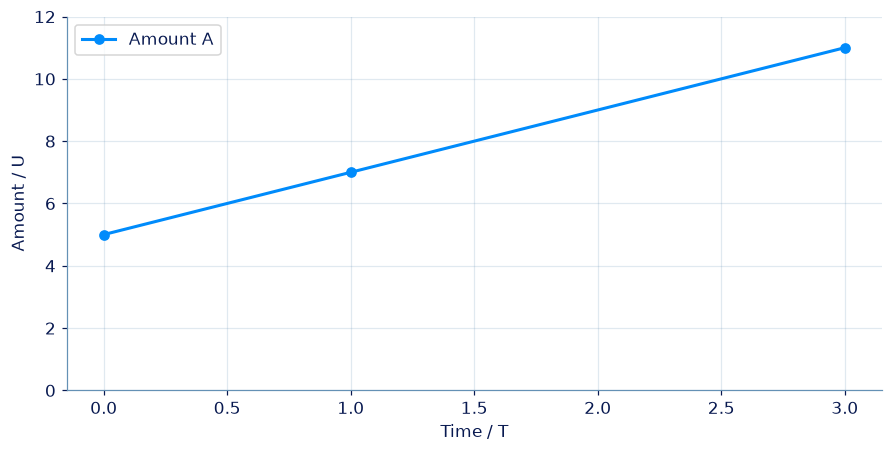

In [2]:
def accumulate(initial, durations, inflows, outflows):
    path = [initial]
    for h, u, v in zip(durations, inflows, outflows):
        path.append(path[-1] + h*(u-v))
    return path

amounts = accumulate(initial, durations, inflows, outflows)
times = [0, 1, 3]
assert amounts == [5, 7, 11]
total_in = sum(h*u for h,u in zip(durations,inflows))
total_out = sum(h*v for h,v in zip(durations,outflows))
assert amounts[-1]-initial == total_in-total_out
fig, ax = plt.subplots()
ax.plot(times, amounts, 'o-', label='Amount A')
ax.set(xlabel='Time / T', ylabel='Amount / U', ylim=(0, 12))
ax.legend()
plt.show()

## 对照实验

比较两类错误。第一类漏掉 h，只有恰好所有段长为 1 时才可能蒙混过关。第二类在算出负总量后把它改成零，图看起来合理了，账目却多出物质。

In [3]:
wrong_final = initial + sum(u-v for u,v in zip(inflows,outflows))
print('漏掉时长得到', wrong_final, 'U；正确终点为', amounts[-1], 'U')
failure = accumulate(1, [1], [0], [2])
clipped = max(0, failure[-1])
print('原规则末量 =', failure[-1], 'U；裁剪末量 =', clipped, 'U')
print('裁剪后的账目差 =', clipped - (1 + 1*(0-2)), 'U')
assert accumulate(5, [], [], []) == [5]
assert failure == [1, -1]

漏掉时长得到 9 U；正确终点为 11 U
原规则末量 = -1 U；裁剪末量 = 0 U
裁剪后的账目差 = 1 U


## 结果解释

长一点的时段会累积更多净流入，因此不等时长实验能揭露漏乘 h 的错误。负数并不是实际负总量，而是“2 U/T 的流出能持续整个时段”在当前储量下不成立。

可以提出“耗尽后停止流出”的新模型（model），但应重新计算实际输出，而不是保留旧流出又偷偷裁剪状态（state）。本节保留失败值，帮助识别假设的适用范围。

[打开可视化与探索：存量流量与守恒](http://127.0.0.1:8000/chapters/01-02-存量、流量与守恒/explore/)

[本章导览](http://127.0.0.1:8000/chapters/01-02-存量、流量与守恒/)

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：流率要乘以时间

存量（stock）A 的单位为 U，恒定流率（flow rate）q 的单位为 U/T，持续时间 h 的单位为 T。哪项能表示这段时间的流入量？

- **A.** q
- **B.** q/h
- **C.** h×q
- **D.** A+q

[作答：流率要乘以时间](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-rate-amount)

### 第 2 题 · Python 计算题：逐段计算物质收支

边界内初始存量（stock）为 initial。每段的流入和流出速率恒定，但各段时长可以不同。返回起点及每段末的所追踪物质总量（tracked amount）。

**函数与代码模板**

```python
def solve(
    initial: float,
    durations: list[float],
    inflows: list[float],
    outflows: list[float],
) -> list[float]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 起点总量。 | U |
| `durations` | `list[float]` | 每段持续时间。 | T |
| `inflows` | `list[float]` | 各段恒定流入速率。 | U/T |
| `outflows` | `list[float]` | 各段恒定流出速率。 | U/T |

**返回值**

直接返回 amounts（list[float]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `amounts` | `list[float]` | 包含起点，共段数加一项。 | U |

**计算规则**

每段末 = 每段初 + durations[i]×(inflows[i]−outflows[i])。按时间顺序累积；即使得到负数也照实返回，不能裁剪。

**约束与边界**

- 所有数值均为有限数。
- 三个列表等长，长度 0 到 1000。
- initial、流率（flow rate）都在 0 到 1000 之间；0 < durations[i] ≤ 100。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 起点总量。 | 5 | U |
| durations | 每段持续时间。 | [1, 2] | T |
| inflows | 各段恒定流入速率。 | [3, 3] | U/T |
| outflows | 各段恒定流出速率。 | [1, 1] | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 5
durations = [1, 2]
inflows = [3, 3]
outflows = [1, 1]

result = solve(initial, durations, inflows, outflows)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| amounts | 包含起点，共段数加一项。 | [5, 7, 11] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [5, 7, 11]
```

**样例解释**

第一段净流率为 2 U/T，持续 1 T，得到 7 U；第二段同样的净流率持续 2 T，增加 4 U，得到 11 U。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐段计算物质收支](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-balance)

### 第 3 题 · 单项选择题：负数是规则失效的线索

初始存量（stock）1 U，无流入，固定流出 2 U/T，假设持续 1 T 后计算为 −1 U。哪项处理最合理？

- **A.** 直接设为 0，并声称原来的流出 2 U 完全符合守恒。
- **B.** 报告原规则产生负值，并检查“固定流出持续整个时段”的假设。
- **C.** 把 −1 U 解释为真实的负所追踪物质总量（tracked amount）。
- **D.** 删掉这个实验，不必修改解释。

[作答：负数是规则失效的线索](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-negative-stock)

### 第 4 题 · Python 计算题：从收支反求总流出

一段实验只有跨边界流入和流出，没有内部产生或转化。已知起点、终点、持续时间和恒定流入速率，返回该段总流出量。

**函数与代码模板**

```python
def solve(
    initial: float,
    final: float,
    duration: float,
    inflow: float,
) -> float:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `initial` | `float` | 起点所追踪物质总量（tracked amount）。 | U |
| `final` | `float` | 终点总量。 | U |
| `duration` | `float` | 观察持续时间。 | T |
| `inflow` | `float` | 恒定流入速率。 | U/T |

**返回值**

直接返回 total_out（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `total_out` | `float` | 整个时段流出总量，不是流出速率。 | U |

**计算规则**

由 final = initial + duration×inflow − total_out 移项求解。

**约束与边界**

- 所有数值均为有限数。
- 0 ≤ initial, final, inflow ≤ 1000；0 < duration ≤ 100。
- 输入（input）保证总流出量非负。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| initial | 起点所追踪物质总量（tracked amount）。 | 5 | U |
| final | 终点总量。 | 7 | U |
| duration | 观察持续时间。 | 2 | T |
| inflow | 恒定流入速率。 | 3 | U/T |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
initial = 5
final = 7
duration = 2
inflow = 3

result = solve(initial, final, duration, inflow)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| total_out | 整个时段流出总量，不是流出速率。 | 4 | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 4
```

**样例解释**

流入 2×3=6 U，而存量（stock）只增加 2 U，所以流出总量为 4 U；对应平均流出速率才是 2 U/T。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从收支反求总流出](http://127.0.0.1:8000/chapters/01-02-%E5%AD%98%E9%87%8F%E3%80%81%E6%B5%81%E9%87%8F%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p01-infer-outflow)

**进一步阅读**

[MIT 15.871 Assignment 3](https://ocw.mit.edu/courses/15-871-introduction-to-system-dynamics-fall-2013/b950bd7b4f565b7b19145fb16bd55c8e_MIT15_871F13_ass3.pdf)：A—B 部分辨认量、边界及物质连接，C 部分讨论积累，D 部分讨论目标调节。本节数值和代码是独立设计的教学例子。